In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import copy
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn

from scipy.integrate import solve_ivp
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

In [ ]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Proyecto_PINN_HRF"
)

SCENARIO = "motor_lr_m1_left"
SNR_NAME = "snr_5"
REPLICATE = 1

NOISY_FILE = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "noisy"
    / SCENARIO
    / SNR_NAME
    / (
        f"{SCENARIO}_"
        f"{SNR_NAME}_"
        f"rep_{REPLICATE:02d}.csv"
    )
)

EVENT_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "100206"
    / "MNINonLinear"
    / "Results"
    / "tfMRI_MOTOR_LR"
    / "EVs"
    / "rh.txt"
)

PARAMETER_FILE = (
    PROJECT_ROOT
    / "configs"
    / "synthetic_ground_truth.json"
)

HRF_FILE = (
    PROJECT_ROOT
    / "data"
    / "synthetic"
    / "ground_truth_hrf.csv"
)

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "synthetic"
    / "pinn_window_pilot"
)

FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Datos:", NOISY_FILE.exists())
print("Eventos:", EVENT_FILE.exists())
print("Parámetros:", PARAMETER_FILE.exists())
print("HRF:", HRF_FILE.exists())

Datos: True
Eventos: True
Parámetros: True
HRF: True


In [ ]:
data = pd.read_csv(
    NOISY_FILE
)

event_values = np.loadtxt(
    EVENT_FILE,
    ndmin=2,
)

events = pd.DataFrame(
    {
        "onset_s": event_values[:, 0],
        "duration_s": event_values[:, 1],
        "amplitude": event_values[:, 2],
    }
).sort_values(
    "onset_s"
).reset_index(
    drop=True
)

with open(
    PARAMETER_FILE,
    encoding="utf-8",
) as file:
    ground_truth_parameters = json.load(file)

ground_truth_hrf = pd.read_csv(
    HRF_FILE
)

time_full = data[
    "time_s"
].to_numpy(dtype=float)

noisy_full = data[
    "bold_noisy_fraction"
].to_numpy(dtype=float)

clean_full = data[
    "bold_clean_fraction"
].to_numpy(dtype=float)

test_mask = data[
    "test_mask"
].to_numpy(dtype=bool)

display(events)

,onset_s,duration_s,amplitude
0,11.009,12.0,1.0
1,131.892,12.0,1.0


In [ ]:
first_event = events.iloc[0]

SECONDS_BEFORE = 2.0
SECONDS_AFTER = 20.0

window_start_s = (
    float(first_event["onset_s"])
    - SECONDS_BEFORE
)

window_end_s = (
    float(first_event["onset_s"])
    + float(first_event["duration_s"])
    + SECONDS_AFTER
)

window_mask = (
    (time_full >= window_start_s)
    & (time_full <= window_end_s)
)

time_window_absolute = time_full[
    window_mask
]

time_window = (
    time_window_absolute
    - window_start_s
)

noisy_window = noisy_full[
    window_mask
]

clean_window = clean_full[
    window_mask
]

stimulus_onset_relative = (
    float(first_event["onset_s"])
    - window_start_s
)

stimulus_duration_s = float(
    first_event["duration_s"]
)

stimulus_end_relative = (
    stimulus_onset_relative
    + stimulus_duration_s
)

print(
    f"Ventana absoluta: "
    f"{window_start_s:.3f}–{window_end_s:.3f} s"
)

print(
    f"Tiempo relativo: "
    f"{time_window[0]:.3f}–{time_window[-1]:.3f} s"
)

print(
    f"Estímulo relativo: "
    f"{stimulus_onset_relative:.3f}–"
    f"{stimulus_end_relative:.3f} s"
)

print("Puntos observados:", len(time_window))

Ventana absoluta: 9.009–43.009 s
Tiempo relativo: 0.351–33.471 s
Estímulo relativo: 2.000–14.000 s
Puntos observados: 47


In [ ]:
RANDOM_SEED = 20260717

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(
        RANDOM_SEED
    )

torch.use_deterministic_algorithms(
    True,
    warn_only=True,
)

torch.set_default_dtype(
    torch.float64
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Dispositivo:", DEVICE)
print("Precisión:", torch.get_default_dtype())

Dispositivo: cpu
Precisión: torch.float64


In [ ]:
PINN_CONFIG = {
    "hidden_layers": [64, 64, 64],
    "phase_1_epochs": 1200,
    "phase_2_epochs": 3500,
    "phase_1_learning_rate": 1e-3,
    "phase_2_network_learning_rate": 3e-4,
    "phase_2_parameter_learning_rate": 8e-4,
    "lambda_data": 1.0,
    "lambda_physics_phase_1": 5.0,
    "lambda_physics_phase_2": 20.0,
    "lambda_initial": 100.0,
    "lambda_terminal": 5.0,
    "n_collocation": 700,
    "residual_scale": 0.05,
    "active_data_weight": 3.0,
    "lbfgs_max_iterations": 300,
}

INITIAL_PARAMETERS = {
    "epsilon": 0.12,
    "tau": 1.20,
    "alpha": 0.38,
}

PARAMETER_BOUNDS = {
    "epsilon": (0.05, 0.30),
    "tau": (0.50, 2.00),
    "alpha": (0.15, 0.60),
}

In [ ]:
def logit(
    probability: float,
) -> float:
    probability = np.clip(
        probability,
        1e-8,
        1.0 - 1e-8,
    )

    return float(
        np.log(
            probability
            / (1.0 - probability)
        )
    )

In [ ]:
class BoundedScalar(nn.Module):

    def __init__(
        self,
        lower: float,
        upper: float,
        initial: float,
    ):
        super().__init__()

        self.lower = float(lower)
        self.upper = float(upper)

        normalized = (
            (initial - lower)
            / (upper - lower)
        )

        self.raw = nn.Parameter(
            torch.tensor(
                logit(normalized),
                dtype=torch.float64,
            )
        )

    def forward(self):
        return (
            self.lower
            + (
                self.upper
                - self.lower
            )
            * torch.sigmoid(
                self.raw
            )
        )

In [ ]:
class WindowPINN(nn.Module):

    def __init__(
        self,
        maximum_time_s: float,
    ):
        super().__init__()

        self.maximum_time_s = float(
            maximum_time_s
        )

        dimensions = [
            1,
            *PINN_CONFIG["hidden_layers"],
            4,
        ]

        layers = []

        for input_size, output_size in zip(
            dimensions[:-2],
            dimensions[1:-1],
        ):
            layers.append(
                nn.Linear(
                    input_size,
                    output_size,
                )
            )

            layers.append(
                nn.Tanh()
            )

        layers.append(
            nn.Linear(
                dimensions[-2],
                dimensions[-1],
            )
        )

        self.network = nn.Sequential(
            *layers
        )

        final_layer = self.network[-1]

        nn.init.zeros_(
            final_layer.weight
        )

        nn.init.zeros_(
            final_layer.bias
        )

        self.epsilon = BoundedScalar(
            *PARAMETER_BOUNDS["epsilon"],
            INITIAL_PARAMETERS["epsilon"],
        )

        self.tau = BoundedScalar(
            *PARAMETER_BOUNDS["tau"],
            INITIAL_PARAMETERS["tau"],
        )

        self.alpha = BoundedScalar(
            *PARAMETER_BOUNDS["alpha"],
            INITIAL_PARAMETERS["alpha"],
        )

    def states(
        self,
        time_tensor: torch.Tensor,
    ):
        normalized_time = (
            2.0
            * time_tensor
            / self.maximum_time_s
            - 1.0
        )

        raw = self.network(
            normalized_time
        )

        s = (
            0.50
            * torch.tanh(
                raw[:, 0:1]
            )
        )

        f = (
            1.0
            + 0.80
            * torch.tanh(
                raw[:, 1:2]
            )
        )

        v = (
            1.0
            + 0.35
            * torch.tanh(
                raw[:, 2:3]
            )
        )

        q = (
            1.0
            + 0.35
            * torch.tanh(
                raw[:, 3:4]
            )
        )

        return s, f, v, q

    def parameter_values(self):
        return {
            "epsilon": self.epsilon(),
            "tau": self.tau(),
            "alpha": self.alpha(),
        }

    def bold(
        self,
        time_tensor: torch.Tensor,
    ):
        _, _, v, q = self.states(
            time_tensor
        )

        E0 = 0.34
        V0 = 0.02

        k1 = 7.0 * E0
        k2 = 2.0
        k3 = 2.0 * E0 - 0.2

        return V0 * (
            k1 * (1.0 - q)
            + k2 * (
                1.0 - q / v
            )
            + k3 * (1.0 - v)
        )

In [ ]:
def stimulus_torch(
    time_tensor: torch.Tensor,
) -> torch.Tensor:
    active = (
        (time_tensor >= stimulus_onset_relative)
        & (
            time_tensor
            < stimulus_end_relative
        )
    )

    return active.to(
        time_tensor.dtype
    )

In [ ]:
def time_derivative(
    output: torch.Tensor,
    time_tensor: torch.Tensor,
):
    return torch.autograd.grad(
        outputs=output,
        inputs=time_tensor,
        grad_outputs=torch.ones_like(
            output
        ),
        create_graph=True,
        retain_graph=True,
    )[0]

In [ ]:
def physical_residuals(
    model: WindowPINN,
    time_tensor: torch.Tensor,
):
    times = (
        time_tensor
        .detach()
        .clone()
        .requires_grad_(True)
    )

    s, f, v, q = model.states(
        times
    )

    ds_dt = time_derivative(
        s,
        times,
    )

    df_dt = time_derivative(
        f,
        times,
    )

    dv_dt = time_derivative(
        v,
        times,
    )

    dq_dt = time_derivative(
        q,
        times,
    )

    parameters = model.parameter_values()

    epsilon = parameters["epsilon"]
    tau = parameters["tau"]
    alpha = parameters["alpha"]

    kappa_s = 0.65
    kappa_f = 0.41
    E0 = 0.34

    neural_input = stimulus_torch(
        times
    )

    extraction = (
        1.0
        - torch.pow(
            torch.tensor(
                1.0 - E0,
                device=DEVICE,
            ),
            1.0 / f,
        )
    )

    residual_s = (
        ds_dt
        - (
            epsilon * neural_input
            - kappa_s * s
            - kappa_f * (f - 1.0)
        )
    )

    residual_f = (
        df_dt - s
    )

    residual_v = (
        tau * dv_dt
        - (
            f
            - torch.pow(
                v,
                1.0 / alpha,
            )
        )
    )

    residual_q = (
        tau * dq_dt
        - (
            f * extraction / E0
            - torch.pow(
                v,
                1.0 / alpha,
            )
            * q / v
        )
    )

    return {
        "s": residual_s,
        "f": residual_f,
        "v": residual_v,
        "q": residual_q,
    }

In [ ]:
observed_time_tensor = torch.tensor(
    time_window[:, None],
    device=DEVICE,
)

observed_bold_tensor = torch.tensor(
    noisy_window[:, None],
    device=DEVICE,
)

data_scale = float(
    np.std(
        noisy_window,
        ddof=0,
    )
)

data_weights = np.ones(
    len(time_window),
    dtype=float,
)

active_response_mask = (
    (time_window >= stimulus_onset_relative)
    & (
        time_window
        <= stimulus_end_relative + 12.0
    )
)

data_weights[
    active_response_mask
] = PINN_CONFIG[
    "active_data_weight"
]

data_weight_tensor = torch.tensor(
    data_weights[:, None],
    device=DEVICE,
)

collocation_times = np.linspace(
    0.0,
    float(time_window[-1]),
    PINN_CONFIG["n_collocation"],
)

collocation_times = np.unique(
    np.concatenate(
        [
            collocation_times,
            time_window,
        ]
    )
)

for boundary in [
    stimulus_onset_relative,
    stimulus_end_relative,
]:
    collocation_times = collocation_times[
        np.abs(
            collocation_times - boundary
        ) > 0.05
    ]

collocation_tensor = torch.tensor(
    collocation_times[:, None],
    device=DEVICE,
)

print("Puntos observados:", len(time_window))
print("Puntos físicos:", len(collocation_times))
print("Escala BOLD:", data_scale)

Puntos observados: 47
Puntos físicos: 741
Escala BOLD: 0.006951117581788744


In [ ]:
def calculate_losses(
    model: WindowPINN,
    lambda_physics: float,
):
    predicted_bold = model.bold(
        observed_time_tensor
    )

    squared_data_error = (
        (
            predicted_bold
            - observed_bold_tensor
        )
        / data_scale
    ) ** 2

    data_loss = torch.sum(
        data_weight_tensor
        * squared_data_error
    ) / torch.sum(
        data_weight_tensor
    )

    residuals = physical_residuals(
        model,
        collocation_tensor,
    )

    residual_scale = PINN_CONFIG[
        "residual_scale"
    ]

    physics_loss = sum(
        torch.mean(
            (
                residual
                / residual_scale
            ) ** 2
        )
        for residual in residuals.values()
    )

    initial_time = torch.zeros(
        (1, 1),
        device=DEVICE,
    )

    final_time = torch.full(
        (1, 1),
        float(time_window[-1]),
        device=DEVICE,
    )

    s0, f0, v0, q0 = model.states(
        initial_time
    )

    sf, ff, vf, qf = model.states(
        final_time
    )

    initial_loss = (
        torch.mean(s0**2)
        + torch.mean(
            (f0 - 1.0) ** 2
        )
        + torch.mean(
            (v0 - 1.0) ** 2
        )
        + torch.mean(
            (q0 - 1.0) ** 2
        )
    )

    terminal_loss = (
        torch.mean(sf**2)
        + torch.mean(
            (ff - 1.0) ** 2
        )
        + torch.mean(
            (vf - 1.0) ** 2
        )
        + torch.mean(
            (qf - 1.0) ** 2
        )
    )

    total_loss = (
        PINN_CONFIG["lambda_data"]
        * data_loss
        + lambda_physics
        * physics_loss
        + PINN_CONFIG["lambda_initial"]
        * initial_loss
        + PINN_CONFIG["lambda_terminal"]
        * terminal_loss
    )

    return {
        "total": total_loss,
        "data": data_loss,
        "physics": physics_loss,
        "initial": initial_loss,
        "terminal": terminal_loss,
    }

In [ ]:
def train_adam_phase(
    model,
    optimizer,
    n_epochs,
    phase_name,
    lambda_physics,
):
    history = []

    best_loss = np.inf
    best_state = None

    start_time = time.time()

    for epoch in range(
        1,
        n_epochs + 1,
    ):
        model.train()
        optimizer.zero_grad()

        losses = calculate_losses(
            model,
            lambda_physics,
        )

        losses["total"].backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        total_value = float(
            losses["total"]
            .detach()
            .cpu()
        )

        parameters = {
            name: float(
                value.detach().cpu()
            )
            for name, value in (
                model.parameter_values()
            ).items()
        }

        history.append(
            {
                "phase": phase_name,
                "epoch": epoch,
                "total_loss": total_value,
                "data_loss": float(
                    losses["data"]
                    .detach()
                    .cpu()
                ),
                "physics_loss": float(
                    losses["physics"]
                    .detach()
                    .cpu()
                ),
                "initial_loss": float(
                    losses["initial"]
                    .detach()
                    .cpu()
                ),
                "terminal_loss": float(
                    losses["terminal"]
                    .detach()
                    .cpu()
                ),
                **parameters,
            }
        )

        if total_value < best_loss:
            best_loss = total_value
            best_state = copy.deepcopy(
                model.state_dict()
            )

        if (
            epoch == 1
            or epoch % 300 == 0
            or epoch == n_epochs
        ):
            print(
                f"{phase_name} | "
                f"{epoch}/{n_epochs} | "
                f"L={total_value:.5f} | "
                f"Ldata={history[-1]['data_loss']:.5f} | "
                f"Lphys={history[-1]['physics_loss']:.5f} | "
                f"epsilon={parameters['epsilon']:.4f} | "
                f"tau={parameters['tau']:.4f} | "
                f"alpha={parameters['alpha']:.4f}"
            )

    model.load_state_dict(
        best_state
    )

    print(
        f"{phase_name} finalizada en "
        f"{(time.time() - start_time) / 60:.2f} min"
    )

    return pd.DataFrame(history)

In [ ]:
model = WindowPINN(
    maximum_time_s=float(
        time_window[-1]
    )
).to(DEVICE)

model.epsilon.raw.requires_grad_(False)
model.tau.raw.requires_grad_(False)
model.alpha.raw.requires_grad_(False)

optimizer_phase_1 = torch.optim.Adam(
    model.network.parameters(),
    lr=PINN_CONFIG[
        "phase_1_learning_rate"
    ],
)

history_phase_1 = train_adam_phase(
    model=model,
    optimizer=optimizer_phase_1,
    n_epochs=PINN_CONFIG[
        "phase_1_epochs"
    ],
    phase_name="network_warmup",
    lambda_physics=PINN_CONFIG[
        "lambda_physics_phase_1"
    ],
)

network_warmup | 1/1200 | L=12.24774 | Ldata=1.94815 | Lphys=2.05992 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 300/1200 | L=0.91829 | Ldata=0.12266 | Lphys=0.15332 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 600/1200 | L=0.62100 | Ldata=0.09627 | Lphys=0.10364 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 900/1200 | L=0.37576 | Ldata=0.08383 | Lphys=0.05780 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup | 1200/1200 | L=0.26488 | Ldata=0.07805 | Lphys=0.03729 | epsilon=0.1200 | tau=1.2000 | alpha=0.3800
network_warmup finalizada en 0.58 min


In [ ]:
model.epsilon.raw.requires_grad_(True)
model.tau.raw.requires_grad_(True)
model.alpha.raw.requires_grad_(True)

optimizer_phase_2 = torch.optim.Adam(
    [
        {
            "params": model.network.parameters(),
            "lr": PINN_CONFIG[
                "phase_2_network_learning_rate"
            ],
        },
        {
            "params": [
                model.epsilon.raw,
                model.tau.raw,
                model.alpha.raw,
            ],
            "lr": PINN_CONFIG[
                "phase_2_parameter_learning_rate"
            ],
        },
    ]
)

history_phase_2 = train_adam_phase(
    model=model,
    optimizer=optimizer_phase_2,
    n_epochs=PINN_CONFIG[
        "phase_2_epochs"
    ],
    phase_name="inverse_problem",
    lambda_physics=PINN_CONFIG[
        "lambda_physics_phase_2"
    ],
)

inverse_problem | 1/3500 | L=0.88202 | Ldata=0.07768 | Lphys=0.04015 | epsilon=0.1200 | tau=1.1997 | alpha=0.3799
inverse_problem | 300/3500 | L=0.50167 | Ldata=0.11696 | Lphys=0.01915 | epsilon=0.1136 | tau=1.1388 | alpha=0.3756
inverse_problem | 600/3500 | L=0.40300 | Ldata=0.11141 | Lphys=0.01453 | epsilon=0.1136 | tau=1.0983 | alpha=0.3706
inverse_problem | 900/3500 | L=0.38753 | Ldata=0.09687 | Lphys=0.01448 | epsilon=0.1157 | tau=1.0593 | alpha=0.3658
inverse_problem | 1200/3500 | L=0.28715 | Ldata=0.08438 | Lphys=0.01012 | epsilon=0.1181 | tau=1.0242 | alpha=0.3626
inverse_problem | 1500/3500 | L=0.24079 | Ldata=0.06950 | Lphys=0.00855 | epsilon=0.1213 | tau=0.9900 | alpha=0.3584
inverse_problem | 1800/3500 | L=0.21228 | Ldata=0.05845 | Lphys=0.00767 | epsilon=0.1240 | tau=0.9696 | alpha=0.3547
inverse_problem | 2100/3500 | L=0.18506 | Ldata=0.04796 | Lphys=0.00682 | epsilon=0.1272 | tau=0.9548 | alpha=0.3511
inverse_problem | 2400/3500 | L=0.16557 | Ldata=0.04153 | Lphys=0.0061

In [ ]:
lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=0.5,
    max_iter=PINN_CONFIG[
        "lbfgs_max_iterations"
    ],
    history_size=50,
    line_search_fn="strong_wolfe",
)

lbfgs_iterations = {
    "count": 0
}


def closure():
    lbfgs.zero_grad()

    losses = calculate_losses(
        model,
        PINN_CONFIG[
            "lambda_physics_phase_2"
        ],
    )

    losses["total"].backward()

    lbfgs_iterations["count"] += 1

    if (
        lbfgs_iterations["count"] == 1
        or lbfgs_iterations["count"] % 50 == 0
    ):
        parameters = model.parameter_values()

        print(
            f"LBFGS {lbfgs_iterations['count']} | "
            f"L={float(losses['total'].detach().cpu()):.5f} | "
            f"Ldata={float(losses['data'].detach().cpu()):.5f} | "
            f"Lphys={float(losses['physics'].detach().cpu()):.5f} | "
            f"epsilon={float(parameters['epsilon'].detach().cpu()):.4f} | "
            f"tau={float(parameters['tau'].detach().cpu()):.4f} | "
            f"alpha={float(parameters['alpha'].detach().cpu()):.4f}"
        )

    return losses["total"]


lbfgs.step(
    closure
)

LBFGS 1 | L=0.11818 | Ldata=0.02852 | Lphys=0.00446 | epsilon=0.1354 | tau=0.9462 | alpha=0.3404
LBFGS 50 | L=0.10350 | Ldata=0.02773 | Lphys=0.00376 | epsilon=0.1355 | tau=0.9462 | alpha=0.3401
LBFGS 100 | L=0.10097 | Ldata=0.02743 | Lphys=0.00366 | epsilon=0.1357 | tau=0.9464 | alpha=0.3394
LBFGS 150 | L=0.09801 | Ldata=0.02657 | Lphys=0.00357 | epsilon=0.1361 | tau=0.9466 | alpha=0.3380
LBFGS 200 | L=0.09564 | Ldata=0.02597 | Lphys=0.00348 | epsilon=0.1365 | tau=0.9469 | alpha=0.3367
LBFGS 250 | L=0.09384 | Ldata=0.02509 | Lphys=0.00343 | epsilon=0.1369 | tau=0.9472 | alpha=0.3355
LBFGS 300 | L=0.09257 | Ldata=0.02439 | Lphys=0.00341 | epsilon=0.1373 | tau=0.9475 | alpha=0.3344


tensor(0.1182, grad_fn=<AddBackward0>)

In [ ]:
estimated_parameters = {
    name: float(
        value.detach().cpu()
    )
    for name, value in (
        model.parameter_values()
    ).items()
}

parameter_rows = []

for parameter_name in [
    "epsilon",
    "tau",
    "alpha",
]:
    true_value = float(
        ground_truth_parameters[
            parameter_name
        ]
    )

    estimated_value = (
        estimated_parameters[
            parameter_name
        ]
    )

    parameter_rows.append(
        {
            "parameter": parameter_name,
            "true_value": true_value,
            "estimated_value": estimated_value,
            "relative_error_percent": (
                100.0
                * abs(
                    estimated_value
                    - true_value
                )
                / abs(true_value)
            ),
        }
    )

parameter_table = pd.DataFrame(
    parameter_rows
)

display(parameter_table)

,parameter,true_value,estimated_value,relative_error_percent
0,epsilon,0.15,0.137355,8.430214
1,tau,0.98,0.947527,3.313575
2,alpha,0.32,0.334271,4.459547


In [ ]:
forward_parameters = {
    **ground_truth_parameters,
    **estimated_parameters,
}

onsets = events[
    "onset_s"
].to_numpy(dtype=float)

durations = events[
    "duration_s"
].to_numpy(dtype=float)

amplitudes = events[
    "amplitude"
].to_numpy(dtype=float)


def stimulus_numpy(
    current_time: float,
) -> float:
    active = (
        (current_time >= onsets)
        & (
            current_time
            < onsets + durations
        )
    )

    return float(
        np.sum(
            amplitudes[active]
        )
    )


def ode_rhs(
    current_time,
    state,
):
    s, f, v, q = state

    epsilon = forward_parameters[
        "epsilon"
    ]

    tau = forward_parameters[
        "tau"
    ]

    alpha = forward_parameters[
        "alpha"
    ]

    kappa_s = forward_parameters[
        "kappa_s"
    ]

    kappa_f = forward_parameters[
        "kappa_f"
    ]

    E0 = forward_parameters[
        "E0"
    ]

    f_safe = max(f, 1e-8)
    v_safe = max(v, 1e-8)

    extraction = (
        1.0
        - (1.0 - E0) ** (
            1.0 / f_safe
        )
    )

    neural_input = stimulus_numpy(
        current_time
    )

    return [
        (
            epsilon * neural_input
            - kappa_s * s
            - kappa_f * (f - 1.0)
        ),
        s,
        (
            f
            - v_safe ** (
                1.0 / alpha
            )
        ) / tau,
        (
            f * extraction / E0
            - v_safe ** (
                1.0 / alpha
            )
            * q / v_safe
        ) / tau,
    ]

In [ ]:
forward_solution = solve_ivp(
    fun=ode_rhs,
    t_span=(
        float(time_full[0]),
        float(time_full[-1]),
    ),
    y0=[
        0.0,
        1.0,
        1.0,
        1.0,
    ],
    t_eval=time_full,
    max_step=0.02,
    rtol=1e-9,
    atol=1e-11,
)

if not forward_solution.success:
    raise RuntimeError(
        forward_solution.message
    )

forward_s, forward_f, forward_v, forward_q = (
    forward_solution.y
)

V0 = forward_parameters["V0"]
k1 = forward_parameters["k1"]
k2 = forward_parameters["k2"]
k3 = forward_parameters["k3"]

forward_bold = V0 * (
    k1 * (1.0 - forward_q)
    + k2 * (
        1.0
        - forward_q / forward_v
    )
    + k3 * (
        1.0 - forward_v
    )
)

In [ ]:
def calculate_metrics(
    observed,
    predicted,
):
    mse = mean_squared_error(
        observed,
        predicted,
    )

    return {
        "rmse_percent": float(
            100.0 * np.sqrt(mse)
        ),
        "mae_percent": float(
            100.0
            * mean_absolute_error(
                observed,
                predicted,
            )
        ),
        "r2": float(
            r2_score(
                observed,
                predicted,
            )
        ),
        "pearson_r": float(
            np.corrcoef(
                observed,
                predicted,
            )[0, 1]
        ),
    }

In [ ]:
forward_test_metrics = calculate_metrics(
    clean_full[test_mask],
    forward_bold[test_mask],
)

display(
    pd.DataFrame(
        [forward_test_metrics]
    )
)

,rmse_percent,mae_percent,r2,pearson_r
0,0.073004,0.049199,0.989255,0.999983


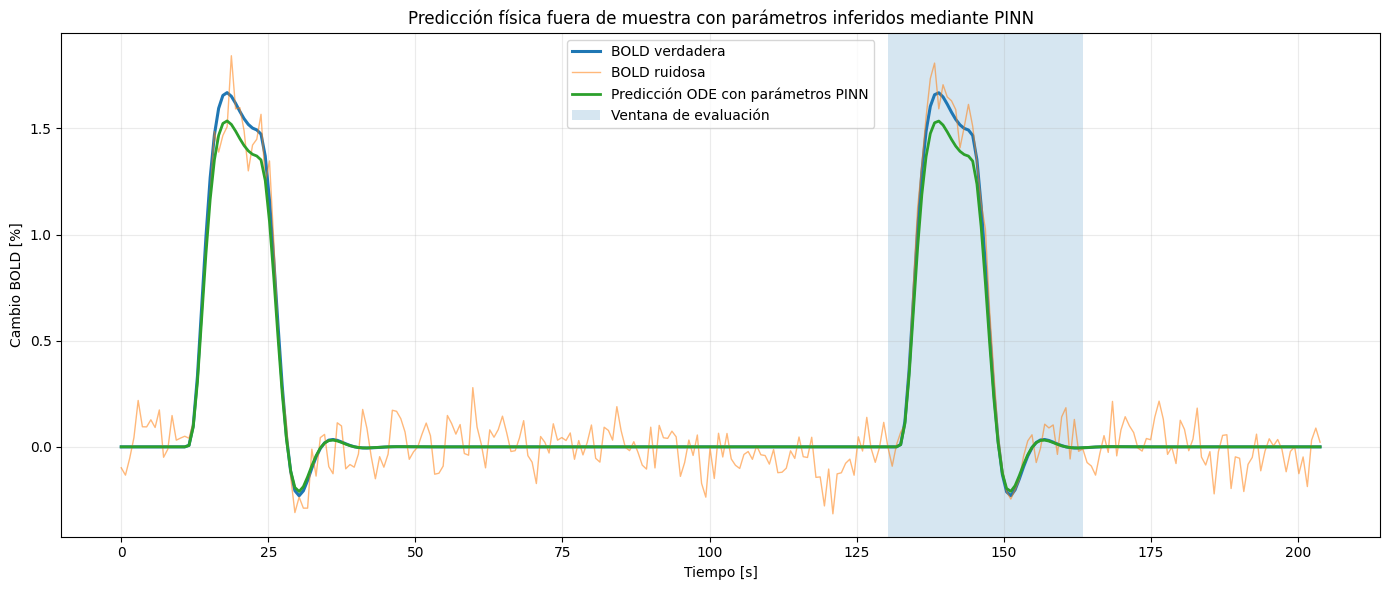

In [ ]:
test_times = time_full[
    test_mask
]

plt.figure(figsize=(14, 6))

plt.plot(
    time_full,
    100.0 * clean_full,
    linewidth=2.2,
    label="BOLD verdadera",
)

plt.plot(
    time_full,
    100.0 * noisy_full,
    linewidth=1.0,
    alpha=0.55,
    label="BOLD ruidosa",
)

plt.plot(
    time_full,
    100.0 * forward_bold,
    linewidth=2.0,
    label="Predicción ODE con parámetros PINN",
)

plt.axvspan(
    float(test_times.min()),
    float(test_times.max()),
    alpha=0.18,
    label="Ventana de evaluación",
)

plt.xlabel("Tiempo [s]")
plt.ylabel("Cambio BOLD [%]")
plt.title(
    "Predicción física fuera de muestra "
    "con parámetros inferidos mediante PINN"
)

plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

figure_path = (
    FIGURES_DIR
    / "pinn_window_forward_prediction_snr5.png"
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()